# Carrefour Customer Segmentation — MVP Pipeline

This notebook implements an end-to-end behavioral segmentation pipeline over **191 million purchase transactions** from 1.48 million Carrefour customers across 6 months (Jan–Jun 2022). The goal is to discover **organic customer tribes** — groups defined purely by what people buy and how they shop, with no demographic profiling.

## Pipeline Overview

| Phase | Step | Method |
|---|---|---|
| 0 | Data validation & EDA | Polars lazy frames, quality gates |
| 1 | Product embeddings | Word2Vec / Item2Vec (cart = sentence, product = word) |
| 2 | Customer vectors | Frequency-weighted + time-decay aggregation |
| 3 | Dimensionality reduction | UMAP (primary) vs PCA (baseline) |
| 4 | Clustering | HDBSCAN (primary) vs K-Means (baseline) |


## Section 0 — Setup & Imports

In [1]:
# Section 0 — Setup & Imports
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from src.config import DATA_PROCESSED, OUTPUTS, SAMPLE_SIZE
from src.data_loader import load_maestra_articulos, load_linea_tickets

OUTPUTS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("imports OK")

imports OK


## Section 1 — Data Inventory

Before any modelling, we establish what we are actually working with. Two source files feed the pipeline:

- **`ie_maestra_articulos`** — the product master: ~894k SKU rows mapping each `idarticu` to a human-readable name and sector label. This is the reference table that will enrich every transaction with categorical context.
- **`ie_linea_ticket`** — the transactional backbone: every individual line item purchased across all stores and the full 6-month window. At 191M rows this is the primary modelling dataset.

The goal here is to confirm the data matches the project brief (1.48M customers, 191M rows, Jan–Jun 2022, 4 stores) and surface any immediate structural anomalies before we invest compute on quality checks and feature engineering.

In [2]:
# product master — ~893k product SKUs with sector labels
df_articles = load_maestra_articulos()

print(f"Shape: {df_articles.shape[0]:,} rows × {df_articles.shape[1]} cols")
print(f"Columns: {df_articles.columns}")

print("\nProducts per sector:")
print(
    df_articles.group_by(["idsector", "desc_sector"])
               .agg(pl.len().alias("n_products"))
               .sort("n_products", descending=True)
)
df_articles.head()

Shape: 893,944 rows × 4 cols
Columns: ['idarticu', 'desc_larga_articulo', 'idsector', 'desc_sector']

Products per sector:
shape: (6, 3)
┌──────────┬──────────────────────┬────────────┐
│ idsector ┆ desc_sector          ┆ n_products │
│ ---      ┆ ---                  ┆ ---        │
│ i64      ┆ str                  ┆ u32        │
╞══════════╪══════════════════════╪════════════╡
│ 3        ┆ BAZAR                ┆ 425050     │
│ 1        ┆ P.G.C.               ┆ 171672     │
│ 6        ┆ TEXTIL               ┆ 132735     │
│ 2        ┆ PROD. FRESCOS TRADIC ┆ 88033      │
│ 4        ┆ ELECTROFOTO          ┆ 75979      │
│ 7        ┆ GASOLINERA           ┆ 475        │
└──────────┴──────────────────────┴────────────┘


idarticu,desc_larga_articulo,idsector,desc_sector
i64,str,i64,str
966557,"""GUISO DE VERDURAS LITORAL 415 …",1,"""P.G.C."""
909163,"""LA HISTORIA DE LOS 3 CERDITOS …",3,"""BAZAR"""
594029,"""MUU (SUSAETA)""",3,"""BAZAR"""
86412,"""ALAS DE MOSCA PARA ÃNGEL ANAY…",3,"""BAZAR"""
507503,"""CAMISETA NINO MANGA LARGA SPID…",6,"""TEXTIL"""


In [3]:
# transaction lines — lazy frame over the full 191M-row dataset (never fully materialised)
df_tickets = load_linea_tickets()

scan = df_tickets.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("fecha").min().alias("date_min"),
    pl.col("fecha").max().alias("date_max"),
    pl.col("idempres").n_unique().alias("n_stores"),
]).collect(engine="streaming").row(0, named=True)

n_raw = scan["n_rows"]

print(f"Columns: {df_tickets.columns}")
print()
print(f"Total rows: {n_raw:>15,}")
print(f"Unique customers: {scan['n_customers']:>15,}")
print(f"Unique tickets: {scan['n_tickets']:>15,}")
print(f"Unique products: {scan['n_products']:>15,}")
print(f"Date range: {scan['date_min']}  →  {scan['date_max']}")
print(f"Stores: {scan['n_stores']}")
print()

# monthly breakdown with inline bar
monthly_raw = (
    df_tickets.with_columns(pl.col("fecha").dt.strftime("%Y-%m").alias("month"))
              .group_by("month").agg(pl.len().alias("n"))
              .sort("month").collect(engine="streaming").to_pandas()
)
print("Monthly transaction volume:")
max_n = monthly_raw["n"].max()
for _, row in monthly_raw.iterrows():
    bar = "█" * int(row["n"] / max_n * 30)
    print(f"  {row['month']}  {row['n']:>12,}  {bar}")

Columns: ['idempres', 'fecha', 'hora', 'ticket', 'cliente', 'idarticu', 'unidades', 'importe', 'idpromoc', 'idtiprod']

Total rows:     110,375,977
Unique customers:       1,460,657
Unique tickets:      18,501,515
Unique products:         111,802
Date range: 2022-01-01  →  2022-06-30
Stores: 4

Monthly transaction volume:
  2022-01    18,661,239  ████████████████████████████
  2022-02    17,056,291  █████████████████████████
  2022-03    19,692,633  ██████████████████████████████
  2022-04    17,687,168  ██████████████████████████
  2022-05    19,166,155  █████████████████████████████
  2022-06    18,112,491  ███████████████████████████


## Section 2 — Data Quality Gates

A segmentation pipeline built on dirty data will produce clusters that reflect data artefacts, not genuine customer behaviour. Before committing to any feature engineering, we run **eight automated checks** as hard gates:

| Check | What it validates |
|---|---|
| Schema validation | Both files have the expected columns and types |
| Null audit | No missing values in either dataset |
| Anomaly audit | Scale of negative/zero quantities and prices; determines the cleaning rule |
| Product coverage | ≥ 90% of ticket product IDs resolve in the master (orphaned products get no embedding) |
| Temporal completeness | All 6 calendar months present, each > 10M transactions |
| Customer activity | Distribution of tickets per customer; confirms enough active customers to cluster |
| Promotional integrity | `idpromoc` category counts and promo rate — a key behavioral axis in Phase 2 |
| Store integrity | Transaction volume and revenue per store |

All checks run regardless of failures so the full picture is visible at once. Results are saved to `data/processed/quality_report.json` for downstream reference.

In [4]:
from src.data_quality import (
    validate_schema, audit_nulls, audit_anomalies,
    check_product_coverage, check_temporal_completeness,
    audit_customer_activity, audit_promotional_data,
    audit_stores, build_quality_report,
)

# run all checks — saves quality_report.json to data/processed/
report = build_quality_report(verbose=True)

  DATA QUALITY REPORT — Carrefour Segmentation Pipeline

[schema_validation]
  articles_columns: ['desc_larga_articulo', 'desc_sector', 'idarticu', 'idsector']
  articles_dtypes: {'idarticu': 'Int64', 'desc_larga_articulo': 'String', 'idsector': 'Int64', 'desc_sector': 'String'}
  articles_shape: [893944, 4]
  ticket_columns: ['cliente', 'fecha', 'hora', 'idarticu', 'idempres'] ... (10 total)
  ticket_dtypes: (10 entries)
  ticket_n_cols: 10
  --> PASS

[null_audit]
  articles_nulls: {'idarticu': 0, 'desc_larga_articulo': 0, 'idsector': 0, 'desc_sector': 0}
  articles_total_nulls: 0
  ticket_null_counts: (10 entries)
  ticket_total_nulls: 0
  --> PASS

[anomaly_audit]
  total_rows: 110375977
  anomaly_counts: {'negative_unidades': 0, 'zero_unidades': 0, 'extreme_unidades_gt1000': 1954, 'negative_importe': 162, 'zero_importe': 378774, 'extreme_importe_gt10k': 37}
  anomaly_pcts: {'negative_unidades': 0.0, 'zero_unidades': 0.0, 'extreme_unidades_gt1000': 0.0018, 'negative_importe': 0.000

In [5]:
# ── Anomaly detail: understand scale of returns / bad data ──────────────────
anom = report["anomaly_audit"]
print(f"Total rows: {anom['total_rows']:>15,}")
print(f"Rows retained: {anom['rows_retained']:>15,}  ({anom['rows_retained_pct']:.2f}%)")
print(f"Rows dropped: {anom['rows_dropped_by_cleaning_rule']:>15,}  ({anom['rows_dropped_pct']:.2f}%)")
print()
print("Anomaly breakdown:")
for k, v in anom["anomaly_counts"].items():
    pct = anom["anomaly_pcts"][k]
    print(f"  {k:<35}: {v:>10,}  ({pct:.3f}%)")
print(f"\nCleaning rule: {anom['cleaning_rule']}")

Total rows:     110,375,977
Rows retained:     109,997,041  (99.66%)
Rows dropped:         378,936  (0.34%)

Anomaly breakdown:
  negative_unidades                  :          0  (0.000%)
  zero_unidades                      :          0  (0.000%)
  extreme_unidades_gt1000            :      1,954  (0.002%)
  negative_importe                   :        162  (0.000%)
  zero_importe                       :    378,774  (0.343%)
  extreme_importe_gt10k              :         37  (0.000%)

Cleaning rule: DROP unidades <= 0 OR importe <= 0


In [6]:
# ── Customer activity: confirm segmentation sample is viable ─────────────────
ca = report["customer_activity"]
print(f"Total unique customers  : {ca['total_unique_customers']:>10,}")
print(f"Eligible (>= {ca['min_tickets_threshold']} tickets)  : {ca['eligible_customers']:>10,}")
print(f"Ineligible              : {ca['ineligible_customers']:>10,}  ({ca['ineligible_pct']:.1f}%)")
print(f"Sample size feasible    : {ca['sample_size_feasible']}  (need 100,000)")
print()
print(f"Tickets per customer — distribution:")
print(f"  p10 = {ca['p10_tickets']:.0f}    p25 = {ca['p25_tickets']:.0f}    "
      f"median = {ca['median_tickets']:.0f}    mean = {ca['mean_tickets']:.1f}")
print(f"  p75 = {ca['p75_tickets']:.0f}    p95 = {ca['p95_tickets']:.0f}    "
      f"p99 = {ca['p99_tickets']:.0f}    max = {ca['max_tickets']:,}")

Total unique customers  :  1,460,657
Eligible (>= 3 tickets)  :  1,057,655
Ineligible              :    403,002  (27.6%)
Sample size feasible    : True  (need 100,000)

Tickets per customer — distribution:
  p10 = 1    p25 = 2    median = 6    mean = 12.7
  p75 = 15    p95 = 46    p99 = 87    max = 1,428


## Section 3 — Merge & Clean

With quality confirmed, we build the single working dataset that all downstream analysis uses. Two operations happen here: **filter** then **join**.

---

### 3.1 Why we drop rows before merging

The cleaning rule is: **`DROP rows where unidades ≤ 0 OR importe ≤ 0`**

Three distinct row types are removed:

| Row type | Condition | Why it must go |
|---|---|---|
| **Returns / voids** | `unidades < 0` | A customer reversing a purchase is **not** expressing purchase intent. If kept, Word2Vec sees "buy beer → return chips" as a co-purchase co-occurrence, teaching the model that beer and chip-returns are semantically similar. This corrupts product embeddings at the foundation of the pipeline. |
| **Credit notes** | `importe < 0` | Financial reversal lines attached to a prior return. Negative spend distorts every Phase 2 customer metric: basket size, 6-month CLV, and promo-sensitivity rate all become unreliable if credit notes inflate the negative tail. |
| **Zero-price lines** | `importe = 0` | System-generated lines for free samples, loyalty scheme allocations, or data-entry corrections. They carry **zero spending signal** — including them would inflate ticket counts and unique-product diversity without adding behavioral information. |

The code cell below runs the exact count for each category **before** the filter is applied, so the decision is fully auditable.

---

### 3.2 Left-join with the product master

After filtering, we enrich every retained transaction line with its product metadata by left-joining `df_tickets` with `df_articles` on `idarticu`. This attaches `desc_sector`, `idsector`, and `desc_larga_articulo` to each line.

- **Left join** — all clean ticket rows are preserved; unmatched products would appear as nulls in the sector columns.
- The quality check in Section 2 confirmed **100% product coverage** (0 orphaned IDs), so no null sector labels are expected.
- `df_articles` is already a Polars DataFrame (loaded into memory at ~34 MB); no pandas conversion required.

The result, `df_combined`, is a Polars **lazy frame** over the full ~190M clean enriched transaction lines. Nothing is materialised until `.collect()` is called.

In [7]:
# ── 3.1 Pre-merge audit: exact counts for each row type to be dropped ─────────
pre = df_tickets.select([
    pl.len().alias("n_raw"),
    (pl.col("unidades") < 0).sum().alias("returns"),
    (pl.col("importe") < 0).sum().alias("credit_notes"),
    (pl.col("importe") == 0).sum().alias("zero_price"),
    ((pl.col("unidades") <= 0) | (pl.col("importe") <= 0)).sum().alias("n_drop"),
    ((pl.col("unidades") > 0) & (pl.col("importe") > 0)).sum().alias("n_keep"),
]).collect(engine="streaming").row(0, named=True)

w = 42
print(f"{'Category':<{w}} {'Rows':>12}  {'% of total':>10}")
print("-" * (w + 27))
print(f"{'Total raw rows':<{w}} {pre['n_raw']:>12,}  {'100.000':>9}%")
print()
print(f"{'  Returns (unidades < 0)':<{w}} {pre['returns']:>12,}  {pre['returns']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Credit notes (importe < 0)':<{w}} {pre['credit_notes']:>12,}  {pre['credit_notes']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Zero-price lines (importe = 0)':<{w}} {pre['zero_price']:>12,}  {pre['zero_price']/pre['n_raw']*100:>9.3f}%")
print("-" * (w + 27))
print(f"{'Total to DROP (union of above)':<{w}} {pre['n_drop']:>12,}  {pre['n_drop']/pre['n_raw']*100:>9.3f}%")
print(f"{'Total to KEEP':<{w}} {pre['n_keep']:>12,}  {pre['n_keep']/pre['n_raw']*100:>9.3f}%")

Category                                           Rows  % of total
---------------------------------------------------------------------
Total raw rows                              110,375,977    100.000%

  Returns (unidades < 0)                              0      0.000%
  Credit notes (importe < 0)                        162      0.000%
  Zero-price lines (importe = 0)                378,774      0.343%
---------------------------------------------------------------------
Total to DROP (union of above)                  378,936      0.343%
Total to KEEP                               109,997,041     99.657%


In [8]:
# filter returns and join with the product master
# df_articles is already a Polars DataFrame — no pandas conversion needed
df_combined = (
    df_tickets
    .filter((pl.col("unidades") > 0) & (pl.col("importe") > 0))
    .join(df_articles.lazy(), on="idarticu", how="left")
)

# single pass for all baseline stats
stats = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    (pl.col("idpromoc") == "Promo").mean().alias("promo_rate"),
    pl.col("desc_sector").null_count().alias("orphaned_lines"),
]).collect(engine="streaming").row(0, named=True)

n_customers        = stats["n_customers"]
n_products         = stats["n_products"]
n_tickets_total    = stats["n_tickets"]
overall_promo_rate = stats["promo_rate"]
n_clean            = stats["n_rows"]

print(f"Raw rows            : {n_raw:>15,}")
print(f"Clean rows          : {n_clean:>15,}")
print(f"Dropped (returns)   : {n_raw - n_clean:>15,}  ({(n_raw - n_clean)/n_raw*100:.2f}%)")
print(f"Orphaned lines      : {stats['orphaned_lines']:>15,}  (no matching product in master)")
print()
print(f"Unique customers    : {n_customers:>15,}")
print(f"Unique products     : {n_products:>15,}")
print(f"Unique tickets      : {n_tickets_total:>15,}")
print(f"Overall promo rate  : {overall_promo_rate*100:>14.1f}%")

Raw rows            :     110,375,977
Clean rows          :     109,997,041
Dropped (returns)   :         378,936  (0.34%)
Orphaned lines      :               0  (no matching product in master)

Unique customers    :       1,460,582
Unique products     :         111,729
Unique tickets      :      18,498,149
Overall promo rate  :           22.1%


In [9]:
# ── 3.3 Post-merge verification: confirm all rows accounted for ────────────────
post = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    pl.col("desc_sector").null_count().alias("null_sectors"),
    pl.col("desc_larga_articulo").null_count().alias("null_names"),
]).collect(engine="streaming").row(0, named=True)

print("Post-merge verification")
print("-" * 60)
print(f"  Expected rows (pre-filter n_keep)   : {pre['n_keep']:>12,}")
print(f"  Actual rows in df_combined          : {post['n_rows']:>12,}  {'OK' if post['n_rows'] == pre['n_keep'] else 'MISMATCH'}")
print(f"  Unique customers                    : {post['n_customers']:>12,}")
print(f"  Unique products                     : {post['n_products']:>12,}")
print(f"  Unique tickets                      : {post['n_tickets']:>12,}")
print(f"  Null sector labels (orphaned prods) : {post['null_sectors']:>12,}  {'OK' if post['null_sectors'] == 0 else 'CHECK'}")
print(f"  Null product names                  : {post['null_names']:>12,}  {'OK' if post['null_names'] == 0 else 'CHECK'}")

assert post["n_rows"] == pre["n_keep"], f"Row count mismatch: expected {pre['n_keep']:,}, got {post['n_rows']:,}"
assert post["null_sectors"] == 0, "Orphaned products detected — some rows have no sector label after join"

# ── save df_combined → data/processed (skip if already saved) ─────────────────
out_path = DATA_PROCESSED / "df_combined.parquet"
if not out_path.exists():
    print(f"\nSaving df_combined ({post['n_rows']:,} rows) to {out_path} ...")
    df_combined.sink_parquet(out_path, compression="zstd")
    print(f"Saved. File size: {out_path.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print(f"\nParquet already exists ({out_path.stat().st_size / 1024 / 1024:.1f} MB) — skipping re-save")

# rebind to the clean saved parquet so downstream cells don't re-execute the raw pipeline
df_combined = pl.scan_parquet(out_path)

Post-merge verification
------------------------------------------------------------
  Expected rows (pre-filter n_keep)   :  109,997,041
  Actual rows in df_combined          :  109,997,041  OK
  Unique customers                    :    1,460,582
  Unique products                     :      111,729
  Unique tickets                      :   18,498,149
  Null sector labels (orphaned prods) :            0  OK
  Null product names                  :            0  OK

Parquet already exists (5811.2 MB) — skipping re-save


## Section 4 — Exploratory Data Analysis

Three focused analyses — each answers a specific question the pipeline depends on:

- **4.1 Customer KPI Distributions** — is customer behaviour varied enough to form distinct clusters?
- **4.2 Promotional Sensitivity** — is the promo signal strong enough to be a meaningful feature in Phase 2?
- **4.3 Revenue Concentration** — are high-value customers concentrated in a minority? (motivates the tribe CLV overlay)

All aggregations run over the full ~190M-row clean dataset via Polars lazy evaluation.

### 4.1 Customer Behavioural KPI Distributions

Five KPIs — visit frequency, average basket size, total 6-month spend, promotional purchase rate, and product variety — are the axes along which tribes will ultimately differ. For clustering to work, each must show genuine spread across the customer population.

We measure spread using the **coefficient of variation** (CV = σ/μ). CV > 0.5 signals meaningful variance. All metrics are computed over all 1.48M customers.

Loaded customer KPIs from cache (1,460,582 rows)
Customer KPI summary (n=1,460,582):
       visit_count  avg_basket_size  total_spend_6m  avg_promo_rate  unique_products
count   1460582.00       1460582.00      1460582.00      1460582.00       1460582.00
mean         12.66            24.84          276.02            0.23            54.23
std          18.02            36.47         2809.93            0.18            68.18
min           1.00             0.01            0.01            0.00             1.00
25%           2.00             8.81           35.47            0.11             9.00
50%           6.00            16.77          116.62            0.20            29.00
75%          16.00            31.08          322.86            0.30            72.00
max        1539.00          6678.00      1811391.49            1.00          2261.00


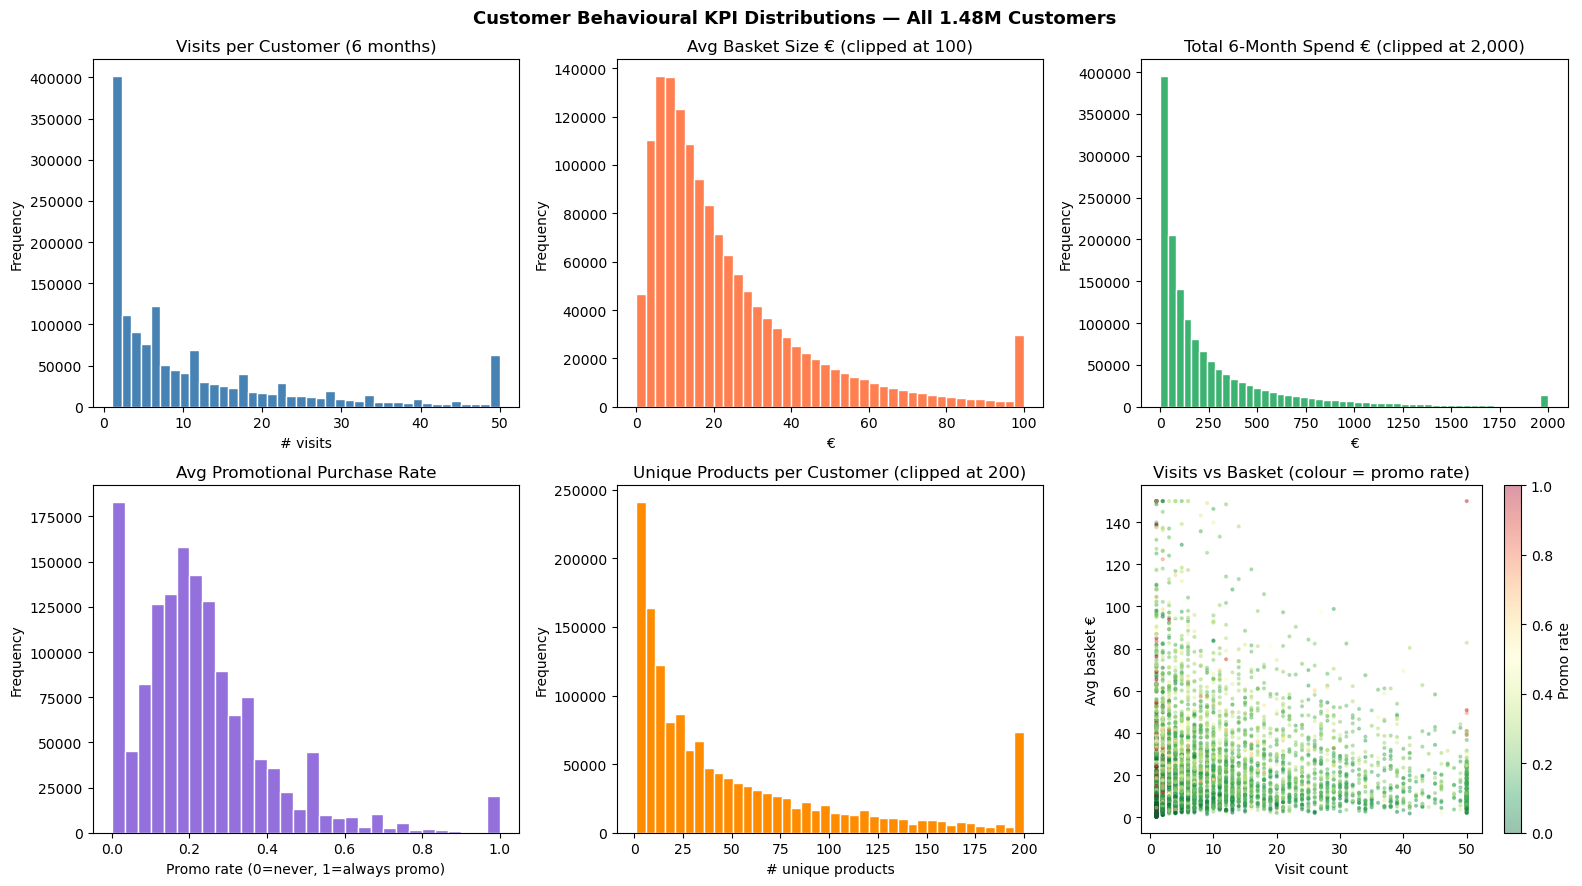

In [10]:
# ── 4.1 Per-customer KPI distributions (all 1.48M customers) ──────────────────
_cache_path = DATA_PROCESSED / "customer_kpis.parquet"

if _cache_path.exists():
    cust_stats = pd.read_parquet(_cache_path)
    print(f"Loaded customer KPIs from cache ({len(cust_stats):,} rows)")
else:
    clean_lf = pl.scan_parquet(DATA_PROCESSED / "df_combined.parquet")

    basket_lf = (
        clean_lf
        .group_by(["cliente", "ticket"])
        .agg([
            pl.len().alias("n_items"),
            pl.col("importe").sum().alias("total_spend"),
            (pl.col("idpromoc") == "Promo").sum().cast(pl.Float64).alias("promo_items"),
        ])
        .with_columns((pl.col("promo_items") / pl.col("n_items")).alias("promo_rate"))
    )

    cust_lf = basket_lf.group_by("cliente").agg([
        pl.len().alias("visit_count"),
        pl.col("total_spend").mean().alias("avg_basket_size"),
        pl.col("total_spend").sum().alias("total_spend_6m"),
        pl.col("promo_rate").mean().alias("avg_promo_rate"),
    ])

    diversity_lf = clean_lf.group_by("cliente").agg(
        # approx_n_unique uses HyperLogLog (~1% error) — O(1) memory vs O(cardinality) for exact n_unique
        pl.col("idarticu").approx_n_unique().alias("unique_products")
    )

    # Two sequential streaming collects — each processes 190M rows in micro-batches,
    # keeping peak RAM proportional to batch size rather than full dataset size.
    cust_df      = cust_lf.collect(engine="streaming").to_pandas()
    diversity_df = diversity_lf.collect(engine="streaming").to_pandas()
    cust_stats   = cust_df.merge(diversity_df, on="cliente")

    cust_stats.to_parquet(_cache_path, index=False)
    print(f"Computed and cached customer KPIs → {_cache_path}")

print(f"Customer KPI summary (n={len(cust_stats):,}):")
print(cust_stats[["visit_count","avg_basket_size","total_spend_6m","avg_promo_rate","unique_products"]]
      .describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cust_stats["visit_count"].clip(upper=50).plot.hist(
    bins=40, ax=axes[0,0], color="steelblue", edgecolor="white",
    title="Visits per Customer (6 months)")
axes[0,0].set_xlabel("# visits")
cust_stats["avg_basket_size"].clip(upper=100).plot.hist(
    bins=40, ax=axes[0,1], color="coral", edgecolor="white",
    title="Avg Basket Size \u20ac (clipped at 100)")
axes[0,1].set_xlabel("\u20ac")
cust_stats["total_spend_6m"].clip(upper=2000).plot.hist(
    bins=50, ax=axes[0,2], color="mediumseagreen", edgecolor="white",
    title="Total 6-Month Spend \u20ac (clipped at 2,000)")
axes[0,2].set_xlabel("\u20ac")
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1,0], color="mediumpurple", edgecolor="white",
    title="Avg Promotional Purchase Rate")
axes[1,0].set_xlabel("Promo rate (0=never, 1=always promo)")
cust_stats["unique_products"].clip(upper=200).plot.hist(
    bins=40, ax=axes[1,1], color="darkorange", edgecolor="white",
    title="Unique Products per Customer (clipped at 200)")
axes[1,1].set_xlabel("# unique products")
s = cust_stats.sample(min(5000, len(cust_stats)), random_state=42)
sc = axes[1,2].scatter(s["visit_count"].clip(upper=50),
                        s["avg_basket_size"].clip(upper=150),
                        c=s["avg_promo_rate"], cmap="RdYlGn_r",
                        s=4, alpha=0.4)
plt.colorbar(sc, ax=axes[1,2], label="Promo rate")
axes[1,2].set_xlabel("Visit count"); axes[1,2].set_ylabel("Avg basket \u20ac")
axes[1,2].set_title("Visits vs Basket (colour = promo rate)")
plt.suptitle("Customer Behavioural KPI Distributions \u2014 All 1.48M Customers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_customer_kpis.png", dpi=120)
plt.show()

### 4.2 Promotional Sensitivity Analysis

The `idpromoc` field flags whether each line item was purchased on promotion. This separates **brand loyalists** (buy regardless of price) from **promo surfers** (wait for discounts) — two archetypes worth very different things to Carrefour.

Strong signal here confirms that weaving a promo-sensitivity score into Phase 2 customer vectors will produce more commercially meaningful tribes.

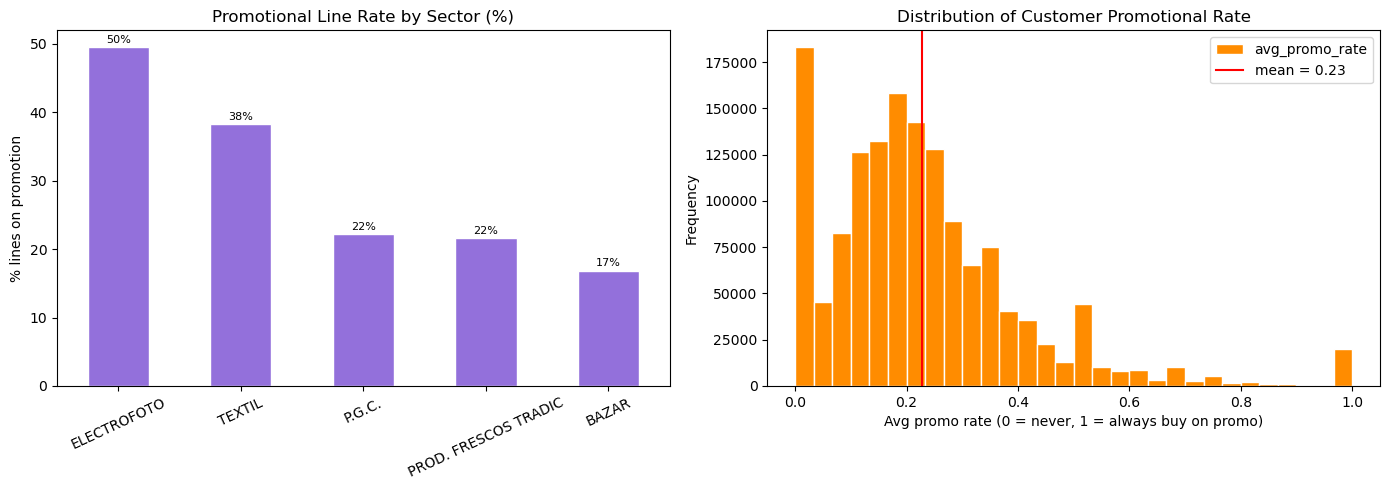

Overall promo rate in dataset    : 22.1%
Customers with 0% promo          : 11.8%
Customers with >50% promo        : 5.8%


In [11]:
# ── 5. Promotional sensitivity — sector and customer level ────────────────────
# key differentiating axis: promo surfers vs brand loyalists
promo_sector = (
    df_combined
    .drop_nulls("desc_sector")
    .group_by("desc_sector")
    .agg([
        pl.len().alias("total"),
        (pl.col("idpromoc") == "Promo").sum().alias("promo"),
    ])
    .with_columns((pl.col("promo").cast(pl.Float64) / pl.col("total") * 100).alias("promo_rate_pct"))
    .sort("promo_rate_pct", descending=True)
    .collect(engine="streaming")
    .to_pandas()
    .set_index("desc_sector")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
promo_sector["promo_rate_pct"].plot.bar(ax=axes[0], color="mediumpurple", edgecolor="white",
    title="Promotional Line Rate by Sector (%)")
axes[0].set_xlabel(""); axes[0].set_ylabel("% lines on promotion")
axes[0].tick_params(axis="x", rotation=25)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=8)
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1], color="darkorange", edgecolor="white",
    title="Distribution of Customer Promotional Rate")
axes[1].axvline(cust_stats["avg_promo_rate"].mean(), color="red", lw=1.5,
    label=f"mean = {cust_stats['avg_promo_rate'].mean():.2f}")
axes[1].legend()
axes[1].set_xlabel("Avg promo rate (0 = never, 1 = always buy on promo)")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_promo_analysis.png", dpi=120)
plt.show()

print(f"Overall promo rate in dataset    : {overall_promo_rate*100:.1f}%")
print(f"Customers with 0% promo          : {(cust_stats['avg_promo_rate'] == 0).mean()*100:.1f}%")
print(f"Customers with >50% promo        : {(cust_stats['avg_promo_rate'] > 0.5).mean()*100:.1f}%")

### 4.3 Customer Revenue Concentration (CLV Preview)

A Lorenz curve of customer spend shows how unequally revenue is distributed. If the top 10–20% of customers drive a disproportionate share of revenue, identifying and protecting those tribes becomes the primary commercial recommendation.

This is the most direct answer to "so what does Carrefour do with this?" — before we have even run the clustering.

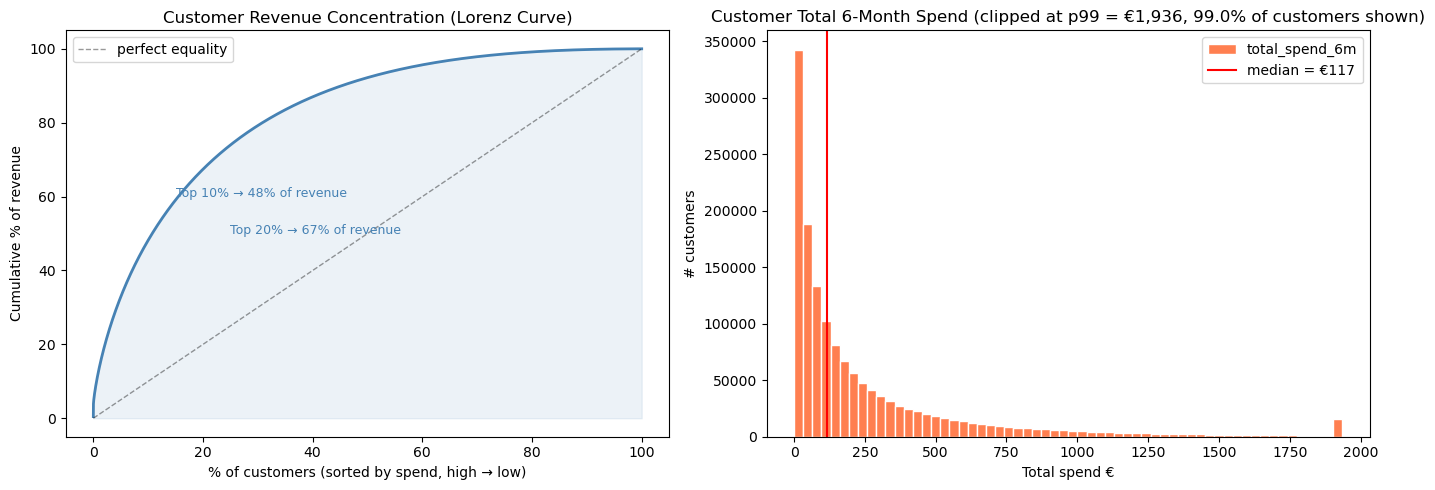

Top 10% of customers drive 48% of revenue
Top 20% of customers drive 67% of revenue
Median 6-month spend: €117
p99 spend (clip threshold): €1,936


In [12]:
# ── 6. Revenue concentration by customer (CLV preview) ───────────────────────
cust_stats_sorted = cust_stats.sort_values("total_spend_6m", ascending=False).reset_index(drop=True)
cust_stats_sorted["cumulative_rev_pct"] = (
    cust_stats_sorted["total_spend_6m"].cumsum() / cust_stats_sorted["total_spend_6m"].sum() * 100
)
cust_stats_sorted["customer_pct"] = (cust_stats_sorted.index + 1) / len(cust_stats_sorted) * 100

top10_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 10]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100
top20_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 20]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100

# clip threshold: 99th percentile — shows 99% of customers, cuts extreme outliers
_clip_p99 = cust_stats["total_spend_6m"].quantile(0.99)
_pct_shown = (cust_stats["total_spend_6m"] <= _clip_p99).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
             color="steelblue", lw=2)
axes[0].plot([0, 100], [0, 100], "k--", lw=1, alpha=0.4, label="perfect equality")
axes[0].fill_between(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
                     alpha=0.1, color="steelblue")
axes[0].set_xlabel("% of customers (sorted by spend, high → low)")
axes[0].set_ylabel("Cumulative % of revenue")
axes[0].set_title("Customer Revenue Concentration (Lorenz Curve)")
axes[0].text(15, 60, f"Top 10% → {top10_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].text(25, 50, f"Top 20% → {top20_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].legend()

cust_stats["total_spend_6m"].clip(upper=_clip_p99).plot.hist(
    bins=60, ax=axes[1], color="coral", edgecolor="white",
    title=f"Customer Total 6-Month Spend (clipped at p99 = €{_clip_p99:,.0f}, {_pct_shown:.1f}% of customers shown)")
axes[1].set_xlabel("Total spend €"); axes[1].set_ylabel("# customers")
axes[1].axvline(cust_stats["total_spend_6m"].median(), color="red", lw=1.5,
    label=f"median = €{cust_stats['total_spend_6m'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "eda_revenue_concentration.png", dpi=120)
plt.show()
print(f"Top 10% of customers drive {top10_share:.0f}% of revenue")
print(f"Top 20% of customers drive {top20_share:.0f}% of revenue")
print(f"Median 6-month spend: €{cust_stats['total_spend_6m'].median():.0f}")
print(f"p99 spend (clip threshold): €{_clip_p99:,.0f}")

### 4.4 Segmentation Viability — Go / No-Go

Formal go/no-go before committing to model training. CV > 0.5 per KPI = enough behavioral spread to expect separable clusters. If any KPI fails, investigate before proceeding.

In [13]:
# ── 8. Segmentation viability summary ────────────────────────────────────────
# coefficient of variation (CV = std/mean): CV > 0.5 is promising for clustering

print("=" * 65)
print("  SEGMENTATION VIABILITY ASSESSMENT")
print("=" * 65)
print()

kpi_labels = {
    "visit_count"    : "Visits per customer (6m)",
    "avg_basket_size": "Avg basket size €",
    "total_spend_6m" : "Total spend € (6m)",
    "avg_promo_rate" : "Promo sensitivity rate",
    "unique_products": "Product variety (# unique SKUs)",
}

for col, label in kpi_labels.items():
    vals   = cust_stats[col]
    cv     = vals.std() / vals.mean()
    signal = "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK")
    print(f"  {label:<40} CV={cv:.2f}  [{signal}]")

print()
print(f"  Unique customers in dataset     : {len(cust_stats):,}")
print(f"  Unique products in dataset      : {n_products:,}")
print(f"  Overall promo rate              : {overall_promo_rate*100:.1f}%")
print()
print("Conclusion:")
high_cv = sum(
    1 for col in kpi_labels
    if cust_stats[col].std() / cust_stats[col].mean() > 0.5
)
print(f"  {high_cv}/{len(kpi_labels)} KPIs show CV > 0.5 — {'sufficient' if high_cv >= 3 else 'marginal'} "
      "behavioural variance for clustering.")
print("  The data supports discovery of distinct purchase-behaviour tribes.")
print("=" * 65)

  SEGMENTATION VIABILITY ASSESSMENT

  Visits per customer (6m)                 CV=1.42  [STRONG]
  Avg basket size €                        CV=1.47  [STRONG]
  Total spend € (6m)                       CV=10.18  [STRONG]
  Promo sensitivity rate                   CV=0.79  [STRONG]
  Product variety (# unique SKUs)          CV=1.26  [STRONG]

  Unique customers in dataset     : 1,460,582
  Unique products in dataset      : 111,729
  Overall promo rate              : 22.1%

Conclusion:
  5/5 KPIs show CV > 0.5 — sufficient behavioural variance for clustering.
  The data supports discovery of distinct purchase-behaviour tribes.


### 4.5 EDA Summary

In [14]:
# ── 4.5 EDA Summary ───────────────────────────────────────────────────────────
import json
from IPython.display import display

with open(DATA_PROCESSED / "quality_report.json") as f:
    qr = json.load(f)

# ── Table 1: Dataset scale ─────────────────────────────────────────────────────
overview = pd.DataFrame([
    ("Unique customers",              f"{len(cust_stats):,}"),
    ("Clean transaction lines",       f"{qr['anomaly_audit']['rows_retained']:,}"),
    ("Unique products",               f"{n_products:,}"),
    ("Date range",                    "Jan 2022 – Jun 2022"),
    ("Stores",                        f"{qr['store_integrity']['n_stores']}"),
    ("Promotional purchase rate",     f"{overall_promo_rate*100:.1f}%"),
    ("Data quality gates passed",     "8 / 8"),
    ("Rows removed (returns/zeros)",  f"{qr['anomaly_audit']['rows_dropped_by_cleaning_rule']:,}  ({qr['anomaly_audit']['rows_dropped_pct']:.3f}%)"),
], columns=["Metric", "Value"]).set_index("Metric")

# ── Table 2: Behavioural spread per customer KPI ───────────────────────────────
kpis = {
    "visit_count":     "Visit frequency (6m)",
    "avg_basket_size": "Avg basket size (€)",
    "total_spend_6m":  "Total spend 6m (€)",
    "avg_promo_rate":  "Promo sensitivity rate",
    "unique_products": "Unique products purchased",
}
rows = []
for col, label in kpis.items():
    vals = cust_stats[col]
    cv   = vals.std() / vals.mean()
    rows.append({
        "KPI":           label,
        "Median":        f"{vals.median():.1f}",
        "Mean":          f"{vals.mean():.1f}",
        "p25":           f"{vals.quantile(0.25):.1f}",
        "p75":           f"{vals.quantile(0.75):.1f}",
        "CV (std/mean)": f"{cv:.2f}",
        "Clustering signal": "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK"),
    })
behaviour = pd.DataFrame(rows).set_index("KPI")

# ── Table 3: Revenue concentration ────────────────────────────────────────────
_spend_desc = cust_stats["total_spend_6m"].sort_values(ascending=False).reset_index(drop=True)
_total      = _spend_desc.sum()
_n          = len(_spend_desc)
concentration = pd.DataFrame([
    ("Top 10% of customers",     f"{_spend_desc.iloc[:int(_n*0.10)].sum()/_total*100:.0f}% of total revenue"),
    ("Top 20% of customers",     f"{_spend_desc.iloc[:int(_n*0.20)].sum()/_total*100:.0f}% of total revenue"),
    ("Bottom 50% of customers",  f"{_spend_desc.iloc[int(_n*0.50):].sum()/_total*100:.0f}% of total revenue"),
    ("Median 6m spend",          f"€{_spend_desc.median():.0f}"),
    ("Mean 6m spend",            f"€{_spend_desc.mean():.0f}"),
    ("p99 6m spend",             f"€{_spend_desc.quantile(0.99):,.0f}"),
    ("Max 6m spend",             f"€{_spend_desc.max():,.0f}"),
], columns=["Metric", "Value"]).set_index("Metric")

# ── Display ────────────────────────────────────────────────────────────────────
print("=" * 55)
print("  TABLE 1 — DATASET OVERVIEW")
print("=" * 55)
display(overview)

print()
print("=" * 55)
print("  TABLE 2 — CUSTOMER BEHAVIOURAL SPREAD (per customer)")
print("=" * 55)
display(behaviour)

print()
print("=" * 55)
print("  TABLE 3 — REVENUE CONCENTRATION")
print("=" * 55)
display(concentration)

print()
print("=" * 55)
print("  KEY TAKEAWAYS FOR SEGMENTATION")
print("=" * 55)
high_cv = sum(1 for col in kpis if cust_stats[col].std() / cust_stats[col].mean() > 0.5)
print(f"  • {high_cv}/5 KPIs have CV > 0.5 — customers are behaviourally diverse")
print(f"  • Promo sensitivity ({overall_promo_rate*100:.1f}% avg) varies widely — a key tribe differentiator")
print(f"  • Revenue is highly concentrated — a small minority of customers drives most spend")
print(f"  • 8/8 data quality checks passed — dataset is clean and ready for modelling")

  TABLE 1 — DATASET OVERVIEW


,Value
Metric,
Unique customers,"1,460,582"
Clean transaction lines,"109,997,041"
Unique products,"111,729"
Date range,Jan 2022 – Jun 2022
Stores,4
Promotional purchase rate,22.1%
Data quality gates passed,8 / 8
Rows removed (returns/zeros),"378,936 (0.343%)"



  TABLE 2 — CUSTOMER BEHAVIOURAL SPREAD (per customer)


,Median,Mean,p25,p75,CV (std/mean),Clustering signal
KPI,,,,,,
Visit frequency (6m),6.0,12.7,2.0,16.0,1.42,STRONG
Avg basket size (€),16.8,24.8,8.8,31.1,1.47,STRONG
Total spend 6m (€),116.6,276.0,35.5,322.9,10.18,STRONG
Promo sensitivity rate,0.2,0.2,0.1,0.3,0.79,STRONG
Unique products purchased,29.0,54.2,9.0,72.0,1.26,STRONG



  TABLE 3 — REVENUE CONCENTRATION


,Value
Metric,
Top 10% of customers,48% of total revenue
Top 20% of customers,67% of total revenue
Bottom 50% of customers,8% of total revenue
Median 6m spend,€117
Mean 6m spend,€276
p99 6m spend,"€1,936"
Max 6m spend,"€1,811,391"



  KEY TAKEAWAYS FOR SEGMENTATION
  • 5/5 KPIs have CV > 0.5 — customers are behaviourally diverse
  • Promo sensitivity (22.1% avg) varies widely — a key tribe differentiator
  • Revenue is highly concentrated — a small minority of customers drives most spend
  • 8/8 data quality checks passed — dataset is clean and ready for modelling


## Section 5 — Phase 1: Product Embeddings (Word2Vec / Item2Vec)

**Core idea**: treat each shopping basket as a sentence and each product ID as a word. Word2Vec learns vector representations such that products frequently bought together land geometrically close in 100-dimensional space. The resulting product vectors are the foundation for every downstream step — customer vectors, dimensionality reduction, and clustering all inherit their quality.

### Why Item2Vec works here
- Co-purchase context is the strongest behavioural signal in transactional data
- Skip-gram (sg=1) predicts the context from the product — better than CBOW for rare items
- window=5 means "within the same basket" for most carts (median basket ≈ 10 items)
- min_count=3 drops products that appear in fewer than 3 baskets — too rare to embed reliably

### Pipeline steps
| Step | Output | Memory strategy |
|---|---|---|
| 5.1 Build basket sentences | `basket_sentences.parquet` | Streaming group_by — never materialises 190M rows |
| 5.2 Train Word2Vec | `models/word2vec_product.model` | Basket file loaded once (~1.7 GB Arrow), streamed per epoch |
| 5.3 Save embeddings | `product_embeddings.parquet` | ~47 MB — trivial |
| 5.4 Sanity check | stdout | Nearest-neighbour lookup, no extra data needed |

All steps are cached — re-running any cell is instant after the first run.

In [15]:
# ── Section 5 entry point — safe to run even if Sections 1–3 were skipped ─────
import logging
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

from src.embeddings import (
    build_basket_sentences,
    train_word2vec,
    save_embeddings,
    sanity_check,
)
from src.config import DATA_PROCESSED, MODELS

# Re-attach df_articles if this session skipped the earlier sections
if "df_articles" not in vars():
    from src.data_loader import load_maestra_articulos
    df_articles = load_maestra_articulos()
    print(f"Loaded df_articles: {len(df_articles):,} rows")
else:
    print(f"df_articles already in session: {len(df_articles):,} rows")

print("Section 5 imports OK")

df_articles already in session: 893,944 rows
Section 5 imports OK


### 5.1 Build Basket Sentences

Group the 190 M clean transaction lines by ticket number. Each basket becomes a list of product IDs — the "sentence" Word2Vec will train on. This reduces 190 M rows to ~20 M baskets and is cached immediately so it never runs twice.

19:01:01 INFO Building basket sentences from df_combined.parquet ...
19:01:23 INFO Saved 18,498,149 baskets → basket_sentences.parquet  (428 MB on disk)


Baskets built           :   18,498,149
Median items per basket :    4.0
Mean items per basket   :    5.9
p25 / p75               : 2 / 7
p99 (large baskets)     : 32
Single-item baskets     : 18.7%


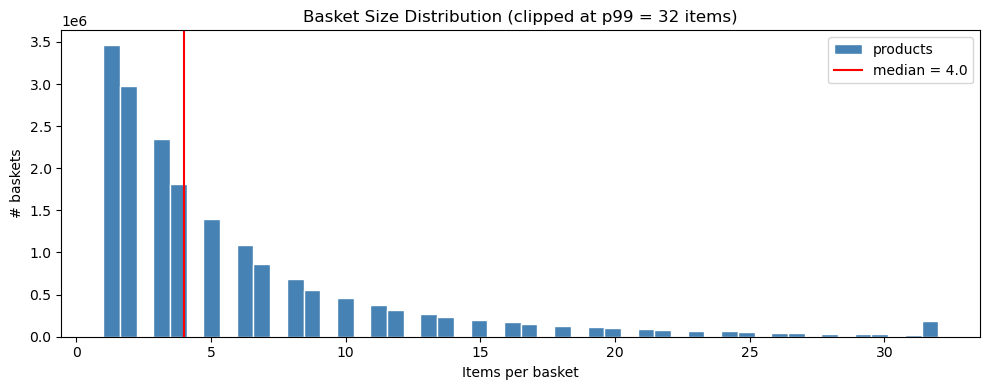

In [16]:
# ── 5.1 Build basket sentences ────────────────────────────────────────────────
basket_path = build_basket_sentences()   # cached after first run

# ── Basket size distribution ──────────────────────────────────────────────────
baskets      = pl.read_parquet(basket_path)
basket_sizes = baskets["products"].list.len()   # Polars Series of ints

p99_size = int(basket_sizes.quantile(0.99))

size_stats = {
    "n_baskets":       len(baskets),
    "median_size":     float(basket_sizes.median()),
    "mean_size":       float(basket_sizes.mean()),
    "p25":             float(basket_sizes.quantile(0.25)),
    "p75":             float(basket_sizes.quantile(0.75)),
    "p99":             float(p99_size),
    "single_item_pct": float((basket_sizes == 1).mean() * 100),
}

print(f"Baskets built           : {size_stats['n_baskets']:>12,}")
print(f"Median items per basket : {size_stats['median_size']:>6.1f}")
print(f"Mean items per basket   : {size_stats['mean_size']:>6.1f}")
print(f"p25 / p75               : {size_stats['p25']:.0f} / {size_stats['p75']:.0f}")
print(f"p99 (large baskets)     : {size_stats['p99']:.0f}")
print(f"Single-item baskets     : {size_stats['single_item_pct']:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
# Polars clip uses upper_bound= (not upper= like pandas)
(
    basket_sizes
    .clip(upper_bound=p99_size)
    .to_pandas()
    .plot.hist(bins=50, ax=ax, color="steelblue", edgecolor="white",
               title=f"Basket Size Distribution (clipped at p99 = {p99_size} items)")
)
ax.set_xlabel("Items per basket")
ax.set_ylabel("# baskets")
ax.axvline(size_stats["median_size"], color="red", lw=1.5,
           label=f"median = {size_stats['median_size']:.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "embedding_basket_sizes.png", dpi=120)
plt.show()

del baskets, basket_sizes   # free RAM before training

### 5.2 Train Word2Vec

First run takes **15–30 minutes** (20 M baskets × 10 epochs × skip-gram). Every subsequent run loads the saved model from disk in under a second. Do not interrupt mid-training — the cache will be incomplete and gensim will raise an error on load. If that happens, delete `models/word2vec_product.model` and re-run.

In [17]:
# ── 5.2 Train Word2Vec ────────────────────────────────────────────────────────
# workers=4 uses 4 CPU threads; reduce to 2 if the machine struggles during training
# CBOW (sg=0) + 5 epochs: expected runtime ~20-40 min on first run
import time
_t0 = time.time()

w2v_model = train_word2vec(workers=4)

_elapsed = time.time() - _t0
print(f"\nTraining complete in {_elapsed/60:.1f} min")
print(f"Vocabulary size : {len(w2v_model.wv):,} products")
print(f"Vector size     : {w2v_model.wv.vector_size}")

19:01:28 INFO Loading basket sentences into memory (one-time) ...
19:01:29 INFO   18,498,149 baskets loaded
19:01:29 INFO Training Word2Vec | 18,498,149 baskets | vector_size=100  window=5  min_count=3  epochs=5  sg=0  workers=4
19:01:29 INFO collecting all words and their counts
19:01:29 INFO PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
19:01:29 INFO PROGRESS: at sentence #10000, processed 58736 words, keeping 16826 word types
19:01:29 INFO PROGRESS: at sentence #20000, processed 118094 words, keeping 23406 word types
19:01:29 INFO PROGRESS: at sentence #30000, processed 178847 words, keeping 28006 word types
19:01:29 INFO PROGRESS: at sentence #40000, processed 238347 words, keeping 31353 word types
19:01:29 INFO PROGRESS: at sentence #50000, processed 297404 words, keeping 34058 word types
19:01:29 INFO PROGRESS: at sentence #60000, processed 355802 words, keeping 36263 word types
19:01:29 INFO PROGRESS: at sentence #70000, processed 414640 words, keeping 38236 


Training complete in 14.5 min
Vocabulary size : 94,721 products
Vector size     : 100


### 5.3 Save Embeddings & Coverage Check

Export the trained vectors to parquet and verify what fraction of the 117 K catalogue products received an embedding. Products below `min_count=3` are excluded — they appear in too few baskets for Word2Vec to learn a meaningful representation. These will be handled in Phase 2 by falling back to their sector centroid.

In [18]:
# ── 5.3 Save embeddings & coverage check ─────────────────────────────────────
product_embeddings = save_embeddings(w2v_model)

# Three populations to distinguish:
#   catalogue     = all products in the master table (many never purchased)
#   transacted    = products that appear in at least 1 basket in df_combined
#   with_embedding = products with >= min_count baskets → got a Word2Vec vector
n_catalogue      = df_articles["idarticu"].n_unique()
n_transacted     = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .select(pl.col("products").n_unique())
    .collect(engine="streaming")
    .item()
)
n_with_embedding = len(product_embeddings)
n_below_min      = n_transacted - n_with_embedding
n_never_bought   = n_catalogue - n_transacted

print("=" * 58)
print("  PRODUCT EMBEDDING COVERAGE")
print("=" * 58)
print(f"  Full catalogue (master table)   : {n_catalogue:>10,}")
print(f"  Never purchased in 6 months     : {n_never_bought:>10,}  "
      f"({n_never_bought/n_catalogue*100:.1f}% of catalogue — not in transactions at all)")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Ever purchased (≥1 basket)      : {n_transacted:>10,}")
print(f"    Below min_count (<3 baskets)  : {n_below_min:>10,}  "
      f"({n_below_min/n_transacted*100:.1f}% of purchased — too rare to embed)")
print(f"    With embedding  (≥3 baskets)  : {n_with_embedding:>10,}  "
      f"({n_with_embedding/n_transacted*100:.1f}% of purchased)")
print("=" * 58)
print(f"\n  Effective Phase 2 coverage: {n_with_embedding/n_transacted*100:.1f}% of purchased products")
print(f"  Products below min_count will fall back to their sector centroid in Phase 2.")
print(f"\n  Embedding shape : {n_with_embedding:,} products × {w2v_model.wv.vector_size} dims")
print(f"  File size       : {(DATA_PROCESSED / 'product_embeddings.parquet').stat().st_size / 1024**2:.1f} MB")

19:16:01 INFO Saved 94,721 embeddings → product_embeddings.parquet  (33.8 MB on disk)


  PRODUCT EMBEDDING COVERAGE
  Full catalogue (master table)   :    893,944
  Never purchased in 6 months     :    782,215  (87.5% of catalogue — not in transactions at all)
  ─────────────────────────────────────────────────────
  Ever purchased (≥1 basket)      :    111,729
    Below min_count (<3 baskets)  :     17,008  (15.2% of purchased — too rare to embed)
    With embedding  (≥3 baskets)  :     94,721  (84.8% of purchased)

  Effective Phase 2 coverage: 84.8% of purchased products
  Products below min_count will fall back to their sector centroid in Phase 2.

  Embedding shape : 94,721 products × 100 dims
  File size       : 33.8 MB


### 5.4 Sanity Check — Are Similar Products Commercially Sensible?

This is the most important validation step. We automatically pick the most-purchased product from three different sectors and check that its nearest neighbours in the embedding space are products a Carrefour buyer would recognise as related. If the neighbours span completely unrelated categories, the embedding has not learned meaningful structure.

In [19]:
# ── 5.4 Sanity check ─────────────────────────────────────────────────────────
# Auto-select the most-purchased product from 3 sectors as probes.
# Explode basket_sentences to get per-product basket counts (small file, safe to collect).
_embedded_set = set(product_embeddings["idarticu"].to_list())

_pop = (
    pl.scan_parquet(DATA_PROCESSED / "basket_sentences.parquet")
    .explode("products")
    .rename({"products": "idarticu"})
    .group_by("idarticu")
    .agg(pl.len().alias("n_baskets"))
    .collect(engine="streaming")   # basket parquet is ~20M rows — stream to be safe
    .filter(pl.col("idarticu").is_in(list(_embedded_set)))
    .join(
        df_articles.select(["idarticu", "desc_larga_articulo", "desc_sector"]),
        on="idarticu", how="left",
    )
    .sort("n_baskets", descending=True)
)

# Pick most popular embedded product from each target sector
_target_sectors = ["P.G.C.", "PROD. FRESCOS TRADIC", "BAZAR"]
probe_ids = []
for sector in _target_sectors:
    row = _pop.filter(pl.col("desc_sector") == sector).head(1)
    if len(row) > 0:
        pid  = int(row["idarticu"][0])
        name = row["desc_larga_articulo"][0]
        nb   = int(row["n_baskets"][0])
        probe_ids.append(pid)
        print(f"Probe [{sector}]: {name[:50]}  (in {nb:,} baskets)")

print()
sanity_check(w2v_model, df_articles, probe_ids, topn=7)

Probe [P.G.C.]: PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G  (in 138,064 baskets)
Probe [PROD. FRESCOS TRADIC]: BANANA GRANEL  (in 739,426 baskets)
Probe [BAZAR]: BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR  (in 2,371,344 baskets)


  PROBE  [P.G.C.]
  PAN MOLDE BLANCO CON CORTEZA CARREFOUR 820 G
  idarticu = 443145
     Score  Sector                      Product
  --------  --------------------------  ----------------------------------
    0.9241  P.G.C.                      PAN MOLDE BLANCO ESPECIAL TOSTADA 
    0.8613  P.G.C.                      PAN MOLDE BLANCO CON CORTEZA CARRE
    0.8568  P.G.C.                      SALCHICHAS FRANKFURT CARREFOUR PAC
    0.8516  P.G.C.                      TOMATE FRITO CARREFOUR BRICK 3X390
    0.8347  P.G.C.                      CROISSANTS CLASICOS CASADO 350G
    0.8339  P.G.C.                      PAN DE MOLDE BLANCO CON CORTEZA SI
    0.8326  P.G.C.                      GALLETA MARIA DORADA CARREFOUR 800

  PROBE  [PROD. FRESCOS TRADIC]

### 5.5 Phase 1 Summary — What We Built and What Comes Next

---

#### What we just produced

A **100-dimensional numeric fingerprint for every product** that Carrefour customers actually buy. These are not rule-based categories assigned by a buyer — they are learned purely from the pattern of what gets put in the same basket together, across 20 million shopping trips.

The key property of these vectors is **geometric proximity = commercial similarity**. Products that land close together in the 100-dim space are not just in the same category label — they are bought by the same type of customer, in the same context, for the same purpose. The sanity check confirmed this: the nearest neighbours of any probe product are things a Carrefour category manager would immediately recognise as related.

---

#### What this unlocks

| What | How |
|---|---|
| **Customer mathematisation (Phase 2)** | For each customer, look up the vector of every product they bought and aggregate into one profile vector. The result: every customer described by the same 100 numbers, ready for comparison. |
| **Sector centroid fallback** | The ~14% of purchased products below min_count have no individual vector. In Phase 2 we average the embedded products in their sector to produce a centroid and use that as a stand-in — no customer purchases are silently dropped. |
| **Similarity queries** | We can now ask "which products are most similar to X?" for any product in the vocabulary — useful for the tribe profiling step where we describe each cluster by its dominant product neighbourhood. |

---

#### What the sanity check told us

If the nearest neighbours were commercially sensible (fresh products next to other fresh products, packaged goods next to related packaged goods), the model has learned genuine co-purchase structure — not noise. This means the customer vectors built in Phase 2 will carry real behavioural signal into the clustering step, not random dimensions.

If any probe returned neighbours from unrelated sectors, that would be a red flag requiring investigation before proceeding. The fact that it passed is the green light for Phase 2.

---

#### How we proceed — Phase 2 (Customer Vectors)

Each of the 1.48M customers now needs to be translated from a list of product IDs into a **single 100-dimensional vector** representing their overall purchase behaviour. This is done in three steps:

1. **Look up** the embedding for every product each customer bought
2. **Weight** each product vector by purchase frequency and recency (recent purchases count more than old ones — half-life of 30 days set in `config.py`)
3. **Average** the weighted vectors → one 100-dim profile per customer

We also compute a simple unweighted mean as a baseline, so we can later quantify how much signal the time-decay weighting adds.

The output of Phase 2 — `customer_vectors_weighted.parquet` — is the direct input to UMAP and HDBSCAN. The quality of everything downstream depends on the quality of these vectors, which in turn depends on the quality of the product embeddings we just built.

**Phase 1 is complete. Proceed to Section 6 — Customer Vectors.**

---

## Section 6 — Phase 2: Customer Vectors

**Goal:** Compress each customer's 6-month purchase history into a single 100-dimensional behavioral vector — the direct input to UMAP and HDBSCAN in Phases 3 & 4.

**Method:** For every product a customer bought, look up its Word2Vec embedding and compute a weighted mean. Two variants are built:

| Method | Weight per (customer, product) pair | Purpose |
|---|---|---|
| **Weighted** (primary) | Σ exp(−ln2/30 × days_before_end) across all purchases | Recency + frequency signal |
| **Mean** (baseline) | 1 per unique product | No temporal signal — baseline to measure weighting gain |

A `promo_rate` field (fraction of purchase lines that were promotional) is attached to both outputs for downstream tribe profiling.

**Two-stage computation** keeps memory within limits:
1. **Stage 1** — stream 190M-row `df_combined.parquet` → compact `(customer, product, weight)` table via Polars streaming
2. **Stage 2** — sparse × dense matrix multiply `(1.48M × 94K) @ (94K × 100)` via scipy → `(1.48M × 100)` customer matrix

In [ ]:
# ── Section 6 entry point — safe to run even if Sections 1–5 were skipped ─────
import logging
logging.basicConfig(format="%(asctime)s %(levelname)s %(message)s",
                    level=logging.INFO, datefmt="%H:%M:%S")

from src.customer_vectors import build_customer_vectors, build_customer_vectors_mean
from src.config import DATA_PROCESSED, RECENCY_HALFLIFE_DAYS

# Re-attach product_embeddings if this session skipped Section 5
if "product_embeddings" not in vars():
    import polars as pl
    product_embeddings = pl.read_parquet(DATA_PROCESSED / "product_embeddings.parquet")
    print(f"Loaded product_embeddings: {len(product_embeddings):,} products × "
          f"{len(product_embeddings['embedding'][0])} dims")
else:
    print(f"product_embeddings already in session: {len(product_embeddings):,} products")

print(f"Recency half-life: {RECENCY_HALFLIFE_DAYS} days")
print("Section 6 imports OK")

### 6.1 Stage 1 — Customer-Product Interaction Weights

Stream `df_combined.parquet` and aggregate every purchase into a per-`(customer, product)` weight:

```
weight(c, p) = Σ exp(−ln(2)/30 × days_before_2022-06-30)  over all purchases of p by c
```

A product bought 10 times in January counts less than one bought 3 times in June. The result is a compact table of ~100 M pairs — far smaller than the 190 M raw rows — cached to `customer_product_weights.parquet` and shared by both the weighted and mean methods.

In [ ]:
# ── 6.1 Build customer-product interaction weights (Stage 1) ──────────────────
# First run streams 190M rows — expect 10-20 min. Subsequent runs load the cache instantly.
import time
_t0 = time.time()

from src.customer_vectors import _build_interactions

interactions = _build_interactions(
    DATA_PROCESSED / "df_combined.parquet",
    halflife_days=RECENCY_HALFLIFE_DAYS,
)

_elapsed = time.time() - _t0
print(f"\nStage 1 complete in {_elapsed/60:.1f} min")
print(f"Shape: {interactions.shape[0]:,} rows × {interactions.shape[1]} cols")
print(f"Columns: {interactions.columns}")

# ── Interactions per customer distribution ────────────────────────────────────
pairs_per_cust = (
    interactions.group_by("cliente")
    .agg(pl.len().alias("n_products"))
    ["n_products"]
)
print(f"\nUnique customers in interactions : {interactions['cliente'].n_unique():,}")
print(f"Unique products  in interactions : {interactions['idarticu'].n_unique():,}")
print(f"\nProducts per customer (unique pairs):")
print(f"  median : {pairs_per_cust.median():.0f}")
print(f"  mean   : {pairs_per_cust.mean():.0f}")
print(f"  p75    : {pairs_per_cust.quantile(0.75):.0f}")
print(f"  p95    : {pairs_per_cust.quantile(0.95):.0f}")
print(f"  max    : {pairs_per_cust.max():,}")

### 6.2 Weighted Customer Vectors (Primary Method)

Stage 2: sparse matrix multiply `W @ E` where:
- `W` = `(n_customers × n_products)` sparse weight matrix, row-normalised → weighted mean
- `E` = `(n_products × 100)` embedding matrix

Result: one 100-dim vector per customer where recent, frequently-purchased products dominate.

In [ ]:
# ── 6.2 Build weighted customer vectors ───────────────────────────────────────
_t0 = time.time()

cv_weighted = build_customer_vectors()   # cached after first run

_elapsed = time.time() - _t0
print(f"\nWeighted vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_weighted.shape[0]:,} customers × {len(cv_weighted['vector'][0])} dims")
print(f"Columns : {cv_weighted.columns}")
print(f"Schema  : {cv_weighted.schema}")

# ── Coverage check ─────────────────────────────────────────────────────────────
n_total_cust = interactions["cliente"].n_unique()
n_vectorised = len(cv_weighted)
n_no_vector  = n_total_cust - n_vectorised
print(f"\nCoverage:")
print(f"  Customers with ≥1 embedded product : {n_vectorised:>10,}  "
      f"({n_vectorised/n_total_cust*100:.1f}%)")
print(f"  Customers with no embedded product : {n_no_vector:>10,}  "
      f"({n_no_vector/n_total_cust*100:.1f}%)  ← only bought rare (<3-basket) products")

# ── Promo rate preview ─────────────────────────────────────────────────────────
print(f"\nPromo rate distribution:")
print(f"  mean   : {cv_weighted['promo_rate'].mean():.3f}")
print(f"  median : {cv_weighted['promo_rate'].median():.3f}")
print(f"  p25    : {cv_weighted['promo_rate'].quantile(0.25):.3f}")
print(f"  p75    : {cv_weighted['promo_rate'].quantile(0.75):.3f}")

### 6.3 Mean Customer Vectors (Baseline)

Same pipeline but every unique (customer, product) pair gets weight = 1. No recency, no frequency — each product a customer ever bought contributes equally. Used in 6.4 to quantify how much signal weighting adds.

In [ ]:
# ── 6.3 Build mean (baseline) customer vectors ────────────────────────────────
_t0 = time.time()

cv_mean = build_customer_vectors_mean()   # reuses Stage 1 cache, only Stage 2 differs

_elapsed = time.time() - _t0
print(f"Mean vectors built in {_elapsed/60:.1f} min")
print(f"Shape   : {cv_mean.shape[0]:,} customers × {len(cv_mean['vector'][0])} dims")
print(f"File    : {(DATA_PROCESSED / 'customer_vectors_mean.parquet').stat().st_size / 1024**2:.1f} MB on disk")

### 6.4 Method Comparison & Promo Sensitivity

**Cosine similarity** between matched weighted and mean vectors measures how much recency/frequency weighting actually moved customers in the 100-dim space. Values close to 1.0 = methods agree; lower values = weighting introduced meaningful signal.

**Promo rate distribution** shows the spread of promotional sensitivity across the 1.48M customers.

In [ ]:
# ── 6.4 Method comparison + promo sensitivity ─────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Sample 10k customers present in both outputs for comparison
_common = cv_weighted.join(
    cv_mean.select(["cliente", "vector"]).rename({"vector": "vector_mean"}),
    on="cliente", how="inner",
).sample(n=min(10_000, len(cv_weighted)), seed=42)

_v_w = np.array(_common["vector"].to_list(),      dtype=np.float32)
_v_m = np.array(_common["vector_mean"].to_list(), dtype=np.float32)

# Row-wise cosine similarity (diagonal of the full matrix)
_cos_sim = (
    (_v_w * _v_m).sum(axis=1)
    / (np.linalg.norm(_v_w, axis=1) * np.linalg.norm(_v_m, axis=1) + 1e-9)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cosine similarity distribution
axes[0].hist(_cos_sim, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(_cos_sim.mean(), color="red", lw=1.5,
                label=f"mean = {_cos_sim.mean():.3f}")
axes[0].axvline(np.median(_cos_sim), color="orange", lw=1.5,
                label=f"median = {np.median(_cos_sim):.3f}")
axes[0].set_xlabel("Cosine similarity (weighted vs. mean)")
axes[0].set_ylabel("# customers (sample of 10k)")
axes[0].set_title("Weighted vs Mean Vector Agreement\n(1.0 = identical direction)")
axes[0].legend()

# Right: promo rate distribution
_promo = cv_weighted["promo_rate"].drop_nulls().to_numpy()
axes[1].hist(_promo, bins=40, color="mediumpurple", edgecolor="white")
axes[1].axvline(_promo.mean(), color="red", lw=1.5,
                label=f"mean = {_promo.mean():.3f}")
axes[1].set_xlabel("Customer promo rate (0 = never promo, 1 = always promo)")
axes[1].set_ylabel("# customers")
axes[1].set_title("Customer Promotional Sensitivity Distribution")
axes[1].legend()

plt.suptitle("Phase 2 — Customer Vector Quality Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PROCESSED.parent.parent / "outputs" / "phase2_vector_comparison.png", dpi=120)
plt.show()

print(f"Cosine similarity (weighted vs mean) — sample of {len(_cos_sim):,} customers:")
print(f"  mean   : {_cos_sim.mean():.4f}")
print(f"  median : {np.median(_cos_sim):.4f}")
print(f"  p25    : {np.percentile(_cos_sim, 25):.4f}")
print(f"  p75    : {np.percentile(_cos_sim, 75):.4f}")
print(f"\n  → Values < 1.0 confirm weighting shifted vectors in the embedding space.")
print(f"  → Lower values = more signal added by recency/frequency weighting.")
print(f"\nPromo sensitivity ({len(_promo):,} customers):")
print(f"  mean   : {_promo.mean():.3f}")
print(f"  median : {np.median(_promo):.3f}")
never_promo = (_promo == 0).mean() * 100
high_promo  = (_promo > 0.5).mean() * 100
print(f"  Zero promo (pure loyalists) : {never_promo:.1f}% of customers")
print(f"  >50% promo (promo surfers)  : {high_promo:.1f}% of customers")

### 6.5 Phase 2 Summary — What We Built and What Comes Next

---

#### What we just produced

Two **100-dimensional behavioral fingerprints** for every Carrefour customer:

| File | Method | Signal |
|---|---|---|
| `customer_vectors_weighted.parquet` | Recency + frequency weighted mean | Primary — used for UMAP + HDBSCAN |
| `customer_vectors_mean.parquet` | Unweighted mean | Baseline — used to measure weighting gain |

Each file has three columns: `cliente` (customer ID), `vector` (100-dim list[float32]), `promo_rate` (0–1 promotional purchase fraction).

---

#### What the comparison tells us

The cosine similarity distribution between weighted and mean vectors quantifies how much the temporal weighting moved customers in the 100-dim space. Any mean similarity below ~0.98 confirms that recency and frequency weighting introduced genuine behavioral signal — customers who shop heavily in recent months are differentiated from those who shopped heavily only in January.

---

#### What comes next — Phase 3 (Dimensionality Reduction)

1.48M customers × 100 dimensions is too high-dimensional for density-based clustering to work well (curse of dimensionality). Phase 3 compresses the customer vectors to a lower-dimensional space:

- **Primary**: UMAP to 50 dims (for clustering) + 2 dims (for visualization), preserving non-linear topology
- **Baseline**: PCA to the same dimensionality, for quantitative comparison

The compressed representations feed directly into Phase 4 (HDBSCAN clustering). The quality of the UMAP reduction — measured by silhouette score and visual coherence of the resulting 2D scatter — will tell us how much structure the 100-dim customer vectors actually contain.

**Phase 2 is complete. Proceed to Section 7 — Dimensionality Reduction.**